In [1]:
# https://satijalab.org/seurat/articles/multimodal_vignette.html

In [2]:
# ARTICLE CITE-seq : https://www.nature.com/articles/nmeth.4380

In [3]:
# In this vignette, we analyze a dataset of 8,617 cord blood mononuclear cells (CBMCs): 
# transcriptomic measurements are paired with abundance estimates for 11 surface proteins, 
# whose levels are quantified with DNA-barcoded antibodies.

In [4]:
setwd("/home/tanasa/CITEseq")
list.files()

[1] "GSE100866_CBMC_8K_13AB_10X-ADT_umi.csv.gz"        
[2] "GSE100866_CBMC_8K_13AB_10X-RNA_umi.csv.gz"        
[3] "pbmc_10k_protein_v3_filtered_feature_bc_matrix.h5"
[4] "pbmc_10k_v3_filtered_feature_bc_matrix.h5"        
[5] "pbmc_10k_v3_filtered_feature_bc_matrix.tar.gz"    
[6] "pbmc_10k_v3_raw_feature_bc_matrix.h5"             
[7] "pbmc_10k_v3_raw_feature_bc_matrix.tar.gz"

In [5]:
library(Seurat)
library(Matrix)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [6]:
# or MOUSE_ appended to the beginning of each gene
cbmc.rna <- as.sparse(read.csv(file = "GSE100866_CBMC_8K_13AB_10X-RNA_umi.csv.gz",
    sep = ",", header = TRUE, row.names = 1))

# To make life a bit easier going forward, we're going to discard all but the top 100 most
# highly expressed mouse genes, and remove the 'HUMAN_' from the CITE-seq prefix
cbmc.rna <- CollapseSpeciesExpressionMatrix(cbmc.rna)

# Load in the ADT UMI matrix
cbmc.adt <- as.sparse(read.csv(file = "GSE100866_CBMC_8K_13AB_10X-ADT_umi.csv.gz",
    sep = ",", header = TRUE, row.names = 1))

# Note that since measurements were made in the same cells, the two matrices have identical
# column names
all.equal(colnames(cbmc.rna), colnames(cbmc.adt))

[1] TRUE

In [7]:
head(cbmc.rna)

  [[ suppressing 8617 column names ‘CTGTTTACACCGCTAG’, ‘CTCTACGGTGTGGCTC’, ‘AGCAGCCAGGCTCATT’ ... ]]



6 x 8617 sparse Matrix of class "dgCMatrix"
                                                                              
A1BG     . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
A1BG-AS1 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
A1CF     . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
A2M      . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
A2M-AS1  . . . . . . . 1 . . . . . . . . . . . . . . . . . . . . . . . . . . .
A2ML1    . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
                                                                              
A1BG     . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
A1BG-AS1 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
A1CF     . . . . . . 1 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
A2M      . . . . . . . . . . . . . . . . . . . 1 . . . . . . . . . . . . . . .
A2M-AS1 

In [8]:
head(cbmc.adt)

  [[ suppressing 8617 column names ‘CTGTTTACACCGCTAG’, ‘CTCTACGGTGTGGCTC’, ‘AGCAGCCAGGCTCATT’ ... ]]



6 x 8617 sparse Matrix of class "dgCMatrix"
                                                                             
CD3     60   52  89  55  63  82  53  42 103  56  59 233  160   80  50  58  52
CD4     72   49 112  66  80  78  63  59 122  70  52 263  297  118  73  74  67
CD8     76   59  61  56  94  57  61  55  64  80  52  61  105   90  53  75  64
CD45RA 575 3943 682 378 644 479 487 472 540 535 686 526 9467 5857 497 527 521
CD56    64   68  87  58 104  44  64  48 136  91  64  70  319   89  61  51  74
CD16   161  107 117  82 168  92  77  99 235 131 127 114  565  150  98 140  95
                                                                               
CD3     45  69  89  93  59  48 117  40  49  68  48  74 104  50  59   62  57  88
CD4     76  59  77  87  77  71 120  60  54  86  78  87  92  53  64   68  91  92
CD8     86  58  68  73  61  61 118  48  46  71  67  85  83  43  42   55  83  34
CD45RA 478 538 426 485 465 549 995 445 420 590 478 629 690 439 446 4958 586 350
CD56    80

In [9]:
dim(cbmc.rna)

[1] 20501  8617

In [10]:
dim(cbmc.adt)

[1]   13 8617

In [11]:
# Set up a Seurat object with the RNA and ADT data

In [12]:
# creates a Seurat object based on the scRNA-seq data
cbmc <- CreateSeuratObject(counts = cbmc.rna)

# We can see that by default, the cbmc object contains an assay storing RNA measurement
Assays(cbmc)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


[1] "RNA"

In [13]:
# Create a new assay to store ADT information
adt_assay <- CreateAssay5Object(counts = cbmc.adt)

# Add this assay to the previously created Seurat object
cbmc[["ADT"]] <- adt_assay

# Validate that the object now contains multiple assays
Assays(cbmc)

[1] "RNA" "ADT"

In [14]:
rownames(cbmc[["ADT"]])

[1] "CD3"    "CD4"    "CD8"    "CD45RA" "CD56"   "CD16"   "CD10"   "CD11c" 
 [9] "CD14"   "CD19"   "CD34"   "CCR5"   "CCR7"

In [15]:
cbmc[["RNA"]] 

Assay (v5) data with 20501 features for 8617 cells
First 10 features:
 A1BG, A1BG-AS1, A1CF, A2M, A2M-AS1, A2ML1, A4GALT, A4GNT, AAAS, AACS 
Layers:
 counts 

In [16]:
cbmc[["ADT"]] 

Assay (v5) data with 13 features for 8617 cells
First 10 features:
 CD3, CD4, CD8, CD45RA, CD56, CD16, CD10, CD11c, CD14, CD19 
Layers:
 counts 

In [17]:
# Cluster cells on the basis of their scRNA-seq profiles

[1] "RNA"

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
09:45:46 UMAP embedding parameters a = 0.9922 b = 1.112

09:45:46 Read 8617 rows and found 30 numeric columns

09:45:46 Using Annoy for neighbor search, n_neighbors = 30

09:45:46 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

09:45:46 Writing NN index file to temp file /tmp/RtmpFjqvkb/filebf0647f7bc59

09:45:46 Searching Annoy index u

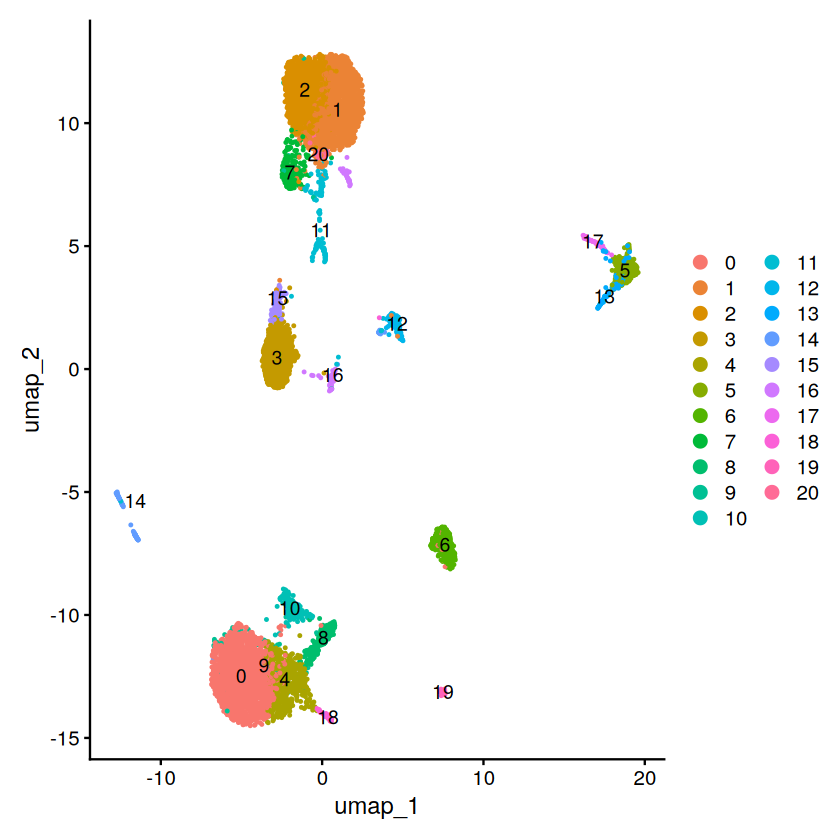

In [18]:
# Note that all operations below are performed on the RNA assay Set and verify that the
# default assay is RNA

DefaultAssay(cbmc) <- "RNA"
DefaultAssay(cbmc)

# Perform visualization and clustering steps
cbmc <- NormalizeData(cbmc)
cbmc <- FindVariableFeatures(cbmc)
cbmc <- ScaleData(cbmc)
cbmc <- RunPCA(cbmc, verbose = FALSE)
cbmc <- FindNeighbors(cbmc, dims = 1:30)
cbmc <- FindClusters(cbmc, resolution = 0.8, verbose = FALSE)
cbmc <- RunUMAP(cbmc, dims = 1:30)

DimPlot(cbmc, label = TRUE)

In [19]:
# Normalize ADT data

library("ggplot2")

DefaultAssay(cbmc) <- "ADT"
cbmc <- NormalizeData(cbmc, normalization.method = "CLR", margin = 2)
DefaultAssay(cbmc) <- "RNA"

# Note that the following command is an alternative but returns the same result
cbmc <- NormalizeData(cbmc, normalization.method = "CLR", margin = 2, assay = "ADT")

# Now, we will visualize CD19 levels for RNA and protein By setting the default assay, we can
# visualize one or the other
DefaultAssay(cbmc) <- "ADT"
p1 <- FeaturePlot(cbmc, "CD19", cols = c("lightgrey", "darkgreen")) + ggtitle("CD19 protein")

DefaultAssay(cbmc) <- "RNA"
p2 <- FeaturePlot(cbmc, "CD19") + ggtitle("CD19 RNA")


Normalizing layer: counts

Normalizing across cells

Normalizing layer: counts

Normalizing across cells



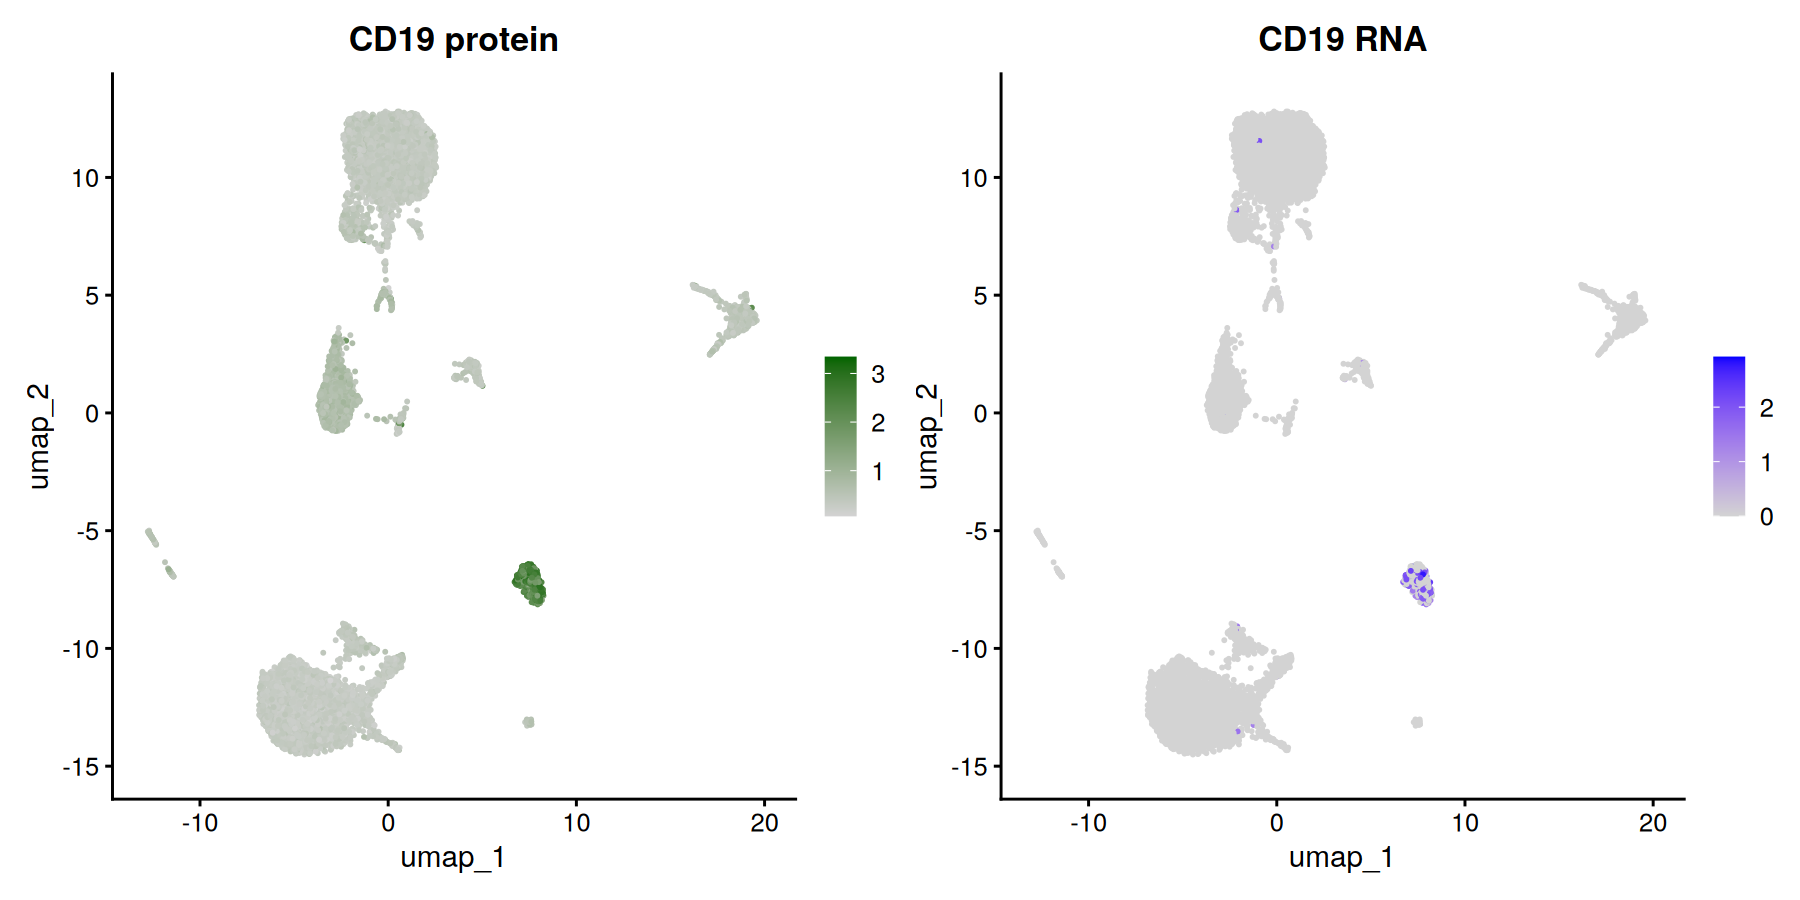

In [20]:
options(repr.plot.width = 12,    # width in inches
        repr.plot.height = 6,    # height in inches
        repr.plot.res = 150)     # resolution


# Place plots side-by-side
p1 | p2

In [21]:
# Alternately, we can use specific assay keys to specify a specific modality Identify the key
# for the RNA and protein assays
Key(cbmc[["RNA"]])

Key(cbmc[["ADT"]])

[1] "rna_"

[1] "adt_"

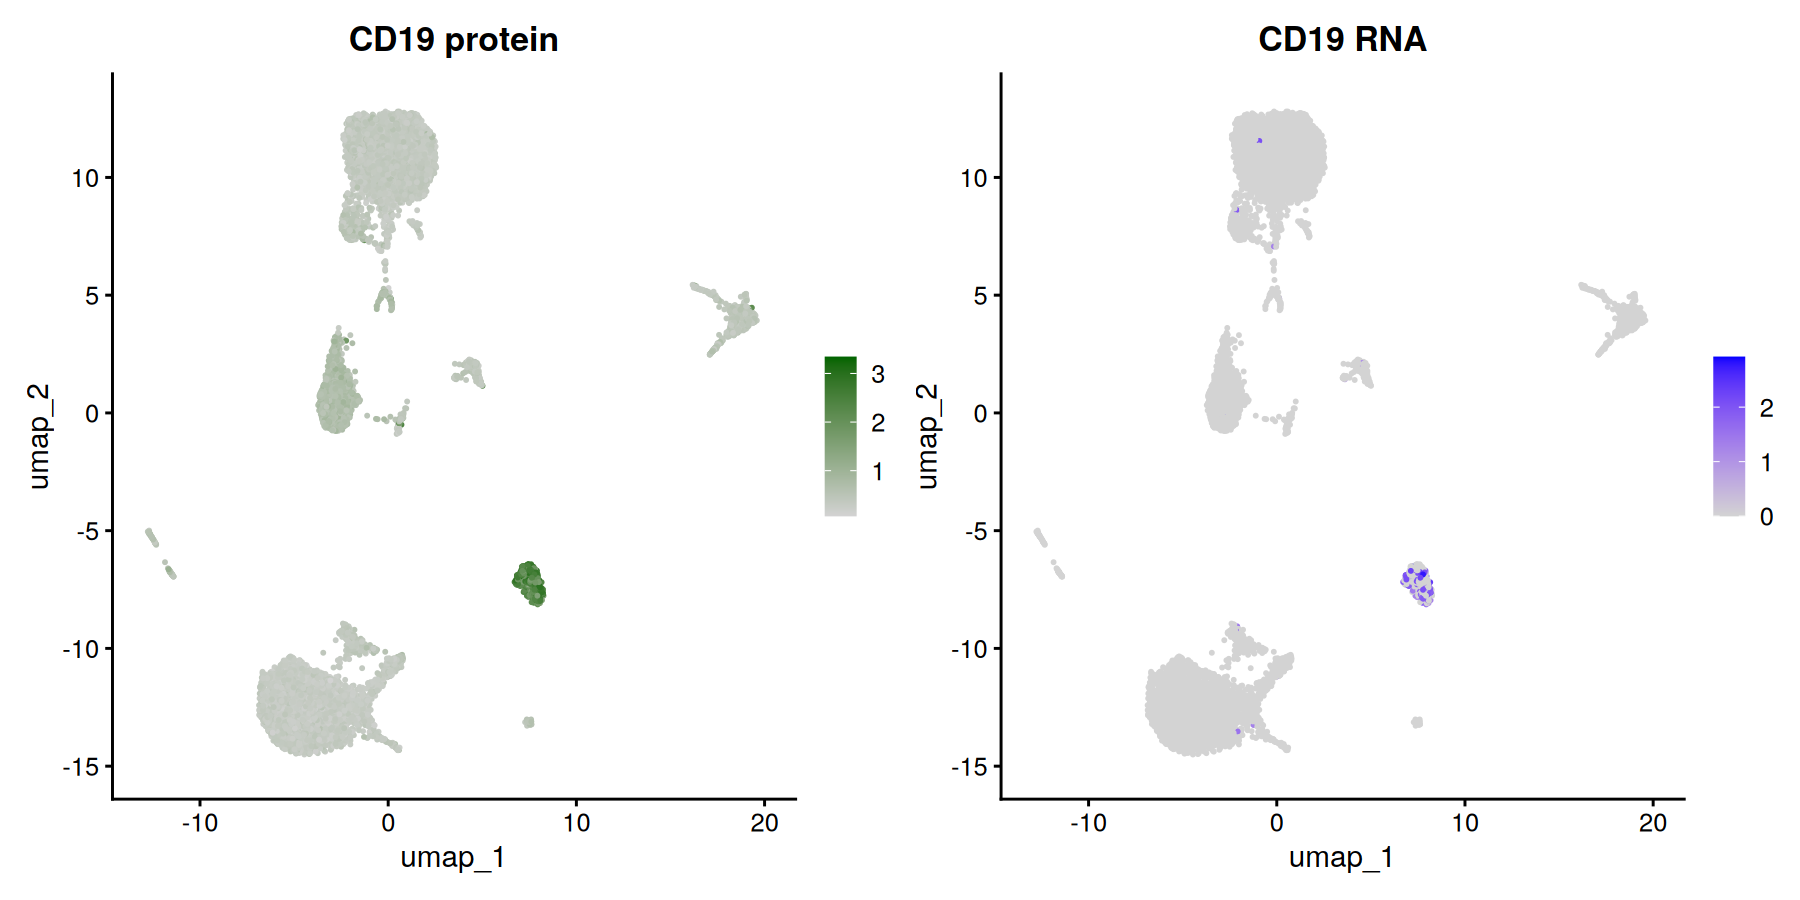

In [22]:
# Now, we can include the key in the feature name, which overrides the default assay
p1 <- FeaturePlot(cbmc, "adt_CD19", cols = c("lightgrey", "darkgreen")) + ggtitle("CD19 protein")
p2 <- FeaturePlot(cbmc, "rna_CD19") + ggtitle("CD19 RNA")
p1 | p2

In [23]:
cat("Identify cell surface markers for scRNA-seq clusters")

Identify cell surface markers for scRNA-seq clusters

In [24]:
# We can leverage our paired CITE-seq measurements to help annotate clusters derived from scRNA-seq, and to identify both protein and RNA markers.

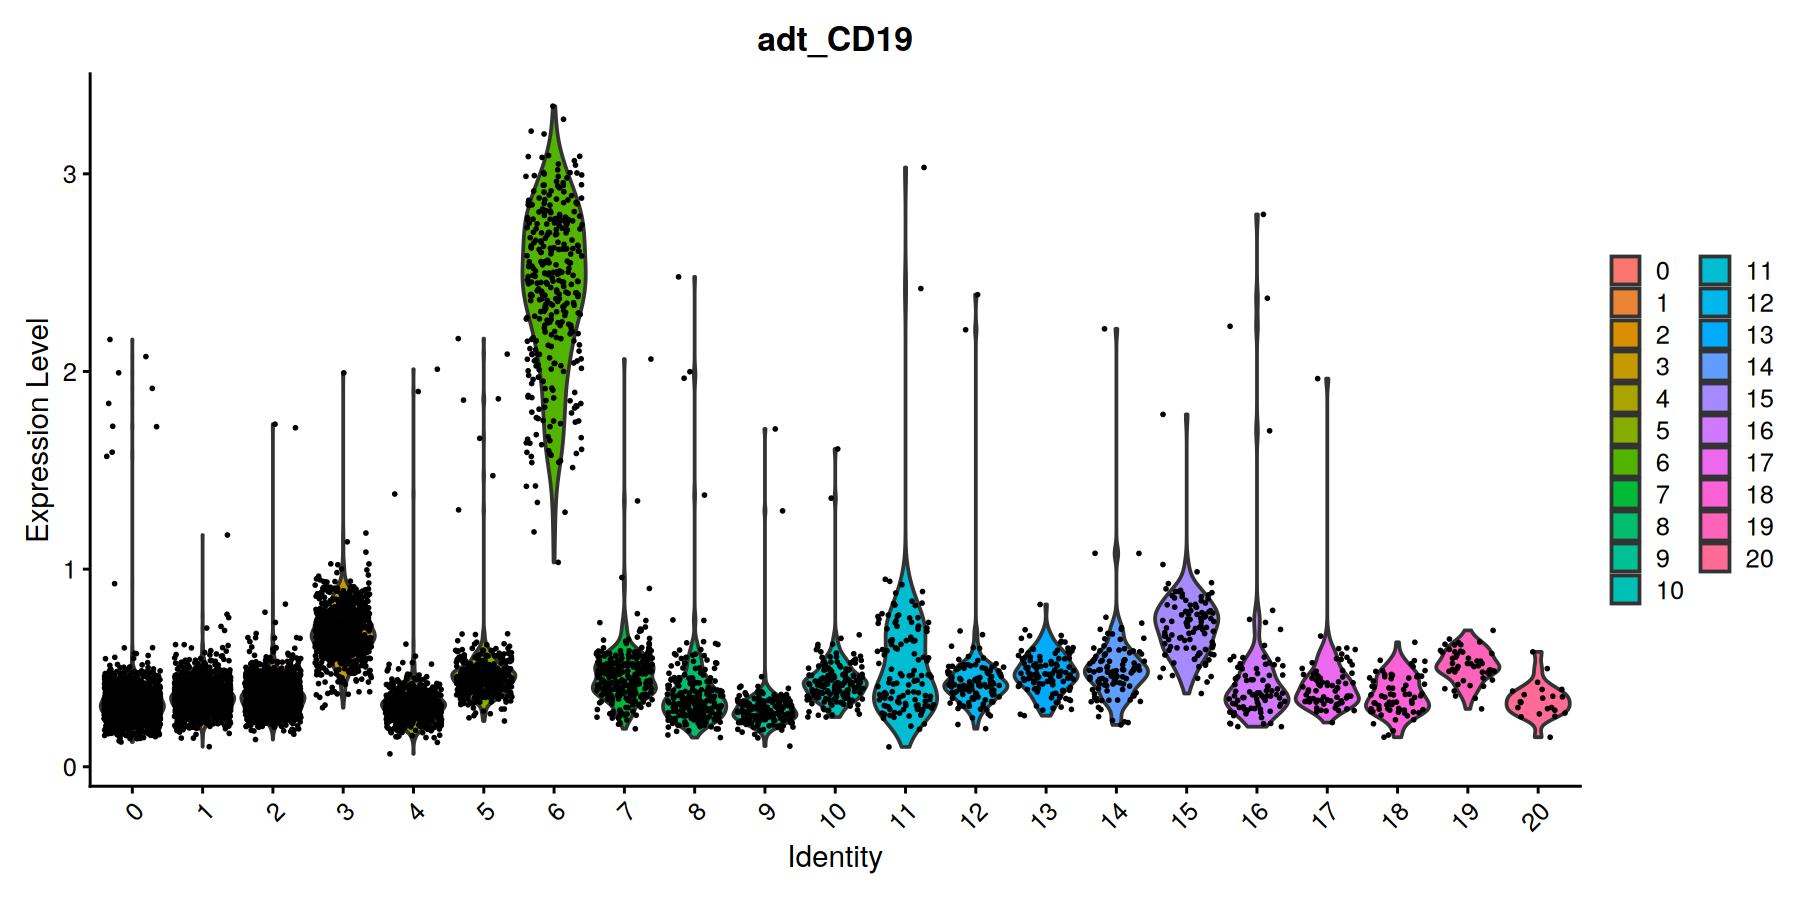

In [25]:
# As we know that CD19 is a B cell marker, we can identify cluster 6 as expressing CD19 on the
# surface
VlnPlot(cbmc, "adt_CD19")

In [26]:
# We can also identify alternative protein and RNA markers for this cluster through
# differential expression

adt_markers <- FindMarkers(cbmc, ident.1 = 6, assay = "ADT")
rna_markers <- FindMarkers(cbmc, ident.1 = 6, assay = "RNA")


In [27]:
adt_markers

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD19,2.067533e-215,2.5741873,1,1,2.687793e-214
CD45RA,8.108073e-109,0.5300346,1,1,1.054049e-107
CD4,1.123162e-107,-1.6707420,1,1,1.460110e-106
CD14,7.212876e-106,-1.0332070,1,1,9.376739e-105
CD3,1.639633e-87,-1.5823056,1,1,2.131523e-86
CCR5,2.552859e-63,0.3753989,1,1,3.318716e-62
CD10,1.708116e-59,0.4455737,1,1,2.220551e-58
CD56,7.671805e-27,0.1618577,1,1,9.973347e-26
CD8,1.042859e-17,-0.9152664,1,1,1.355716e-16


In [28]:
head(adt_markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD19,2.067533e-215,2.5741873,1,1,2.687793e-214
CD45RA,8.108073e-109,0.5300346,1,1,1.054049e-107
CD4,1.123162e-107,-1.6707420,1,1,1.460110e-106
CD14,7.212876e-106,-1.0332070,1,1,9.376739e-105
CD3,1.639633e-87,-1.5823056,1,1,2.131523e-86
CCR5,2.552859e-63,0.3753989,1,1,3.318716e-62


In [29]:
rna_markers

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IGHM,0.000000e+00,6.660187,0.977,0.044,0.000000e+00
CD79A,0.000000e+00,6.748356,0.965,0.045,0.000000e+00
TCL1A,0.000000e+00,7.428099,0.904,0.028,0.000000e+00
CD79B,0.000000e+00,5.525568,0.944,0.089,0.000000e+00
IGHD,0.000000e+00,7.811884,0.857,0.015,0.000000e+00
MS4A1,0.000000e+00,7.523215,0.851,0.016,0.000000e+00
HLA-DQA1,0.000000e+00,3.751012,0.851,0.098,0.000000e+00
VPREB3,0.000000e+00,7.739830,0.684,0.009,0.000000e+00
LINC00926,0.000000e+00,7.307337,0.675,0.011,0.000000e+00


In [30]:
head(rna_markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IGHM,0,6.660187,0.977,0.044,0
CD79A,0,6.748356,0.965,0.045,0
TCL1A,0,7.428099,0.904,0.028,0
CD79B,0,5.525568,0.944,0.089,0
IGHD,0,7.811884,0.857,0.015,0
MS4A1,0,7.523215,0.851,0.016,0


In [31]:
cat("Additional visualizations of multimodal data")

Additional visualizations of multimodal data

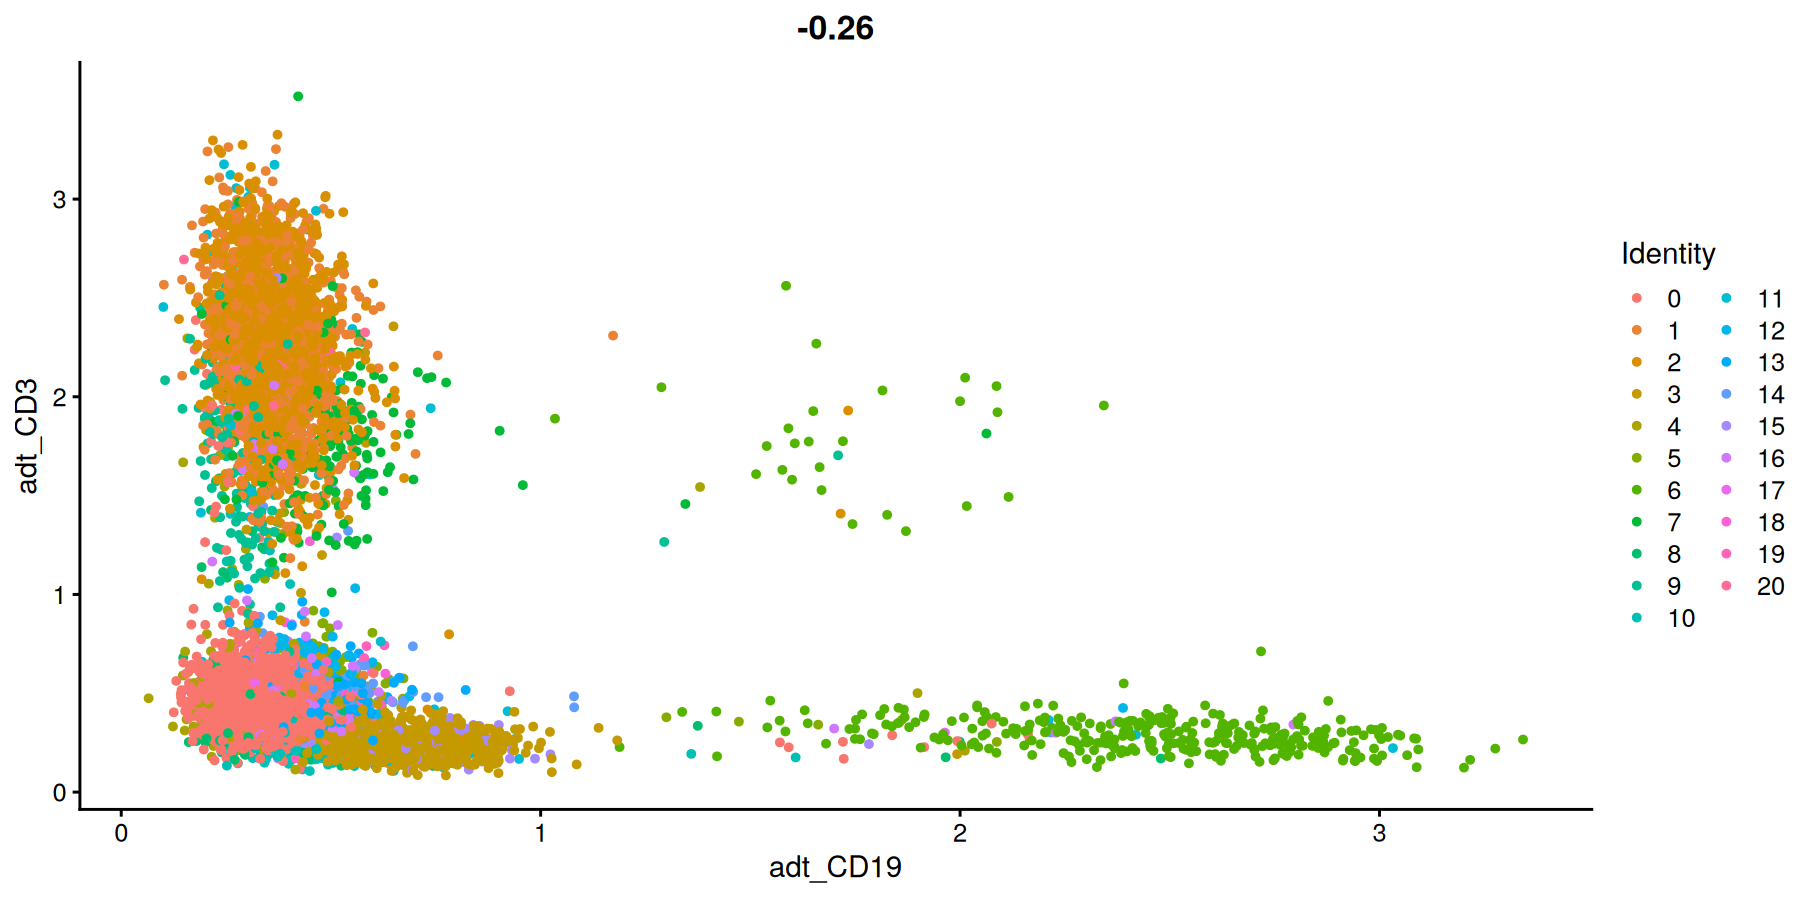

In [32]:
# Draw ADT scatter plots (like biaxial plots for FACS). Note that you can even 'gate' cells if
# desired by using HoverLocator and FeatureLocator
FeatureScatter(cbmc, feature1 = "adt_CD19", feature2 = "adt_CD3")

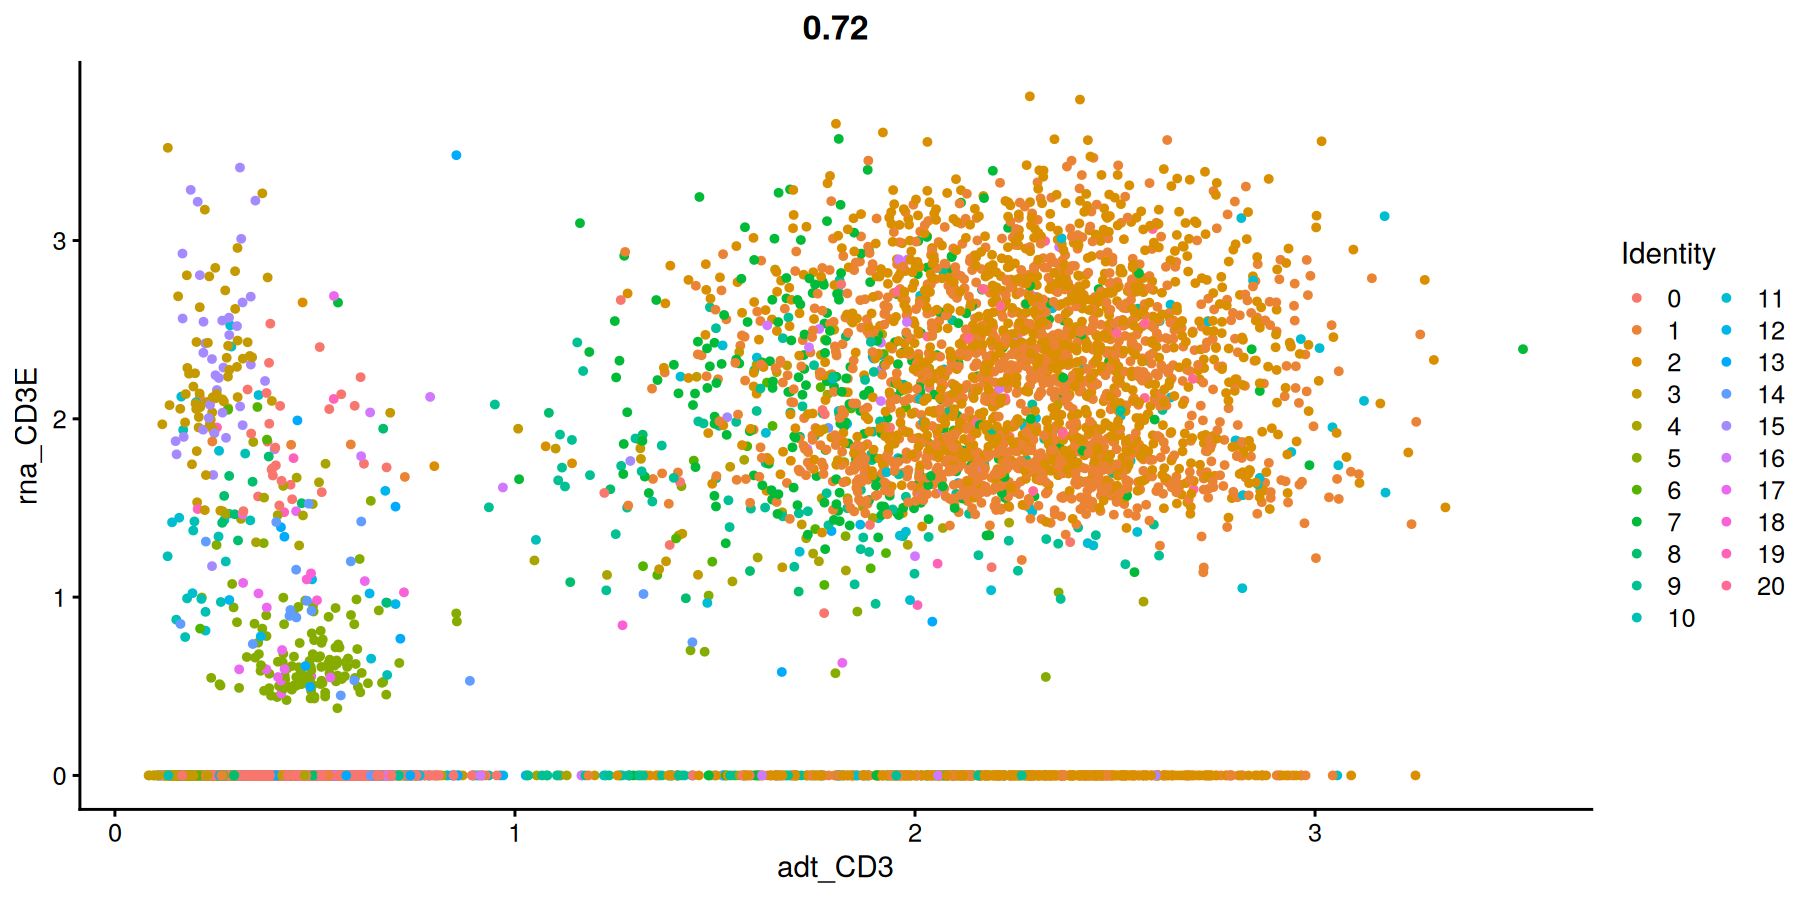

In [33]:
# view relationship between protein and RNA
FeatureScatter(cbmc, feature1 = "adt_CD3", feature2 = "rna_CD3E")

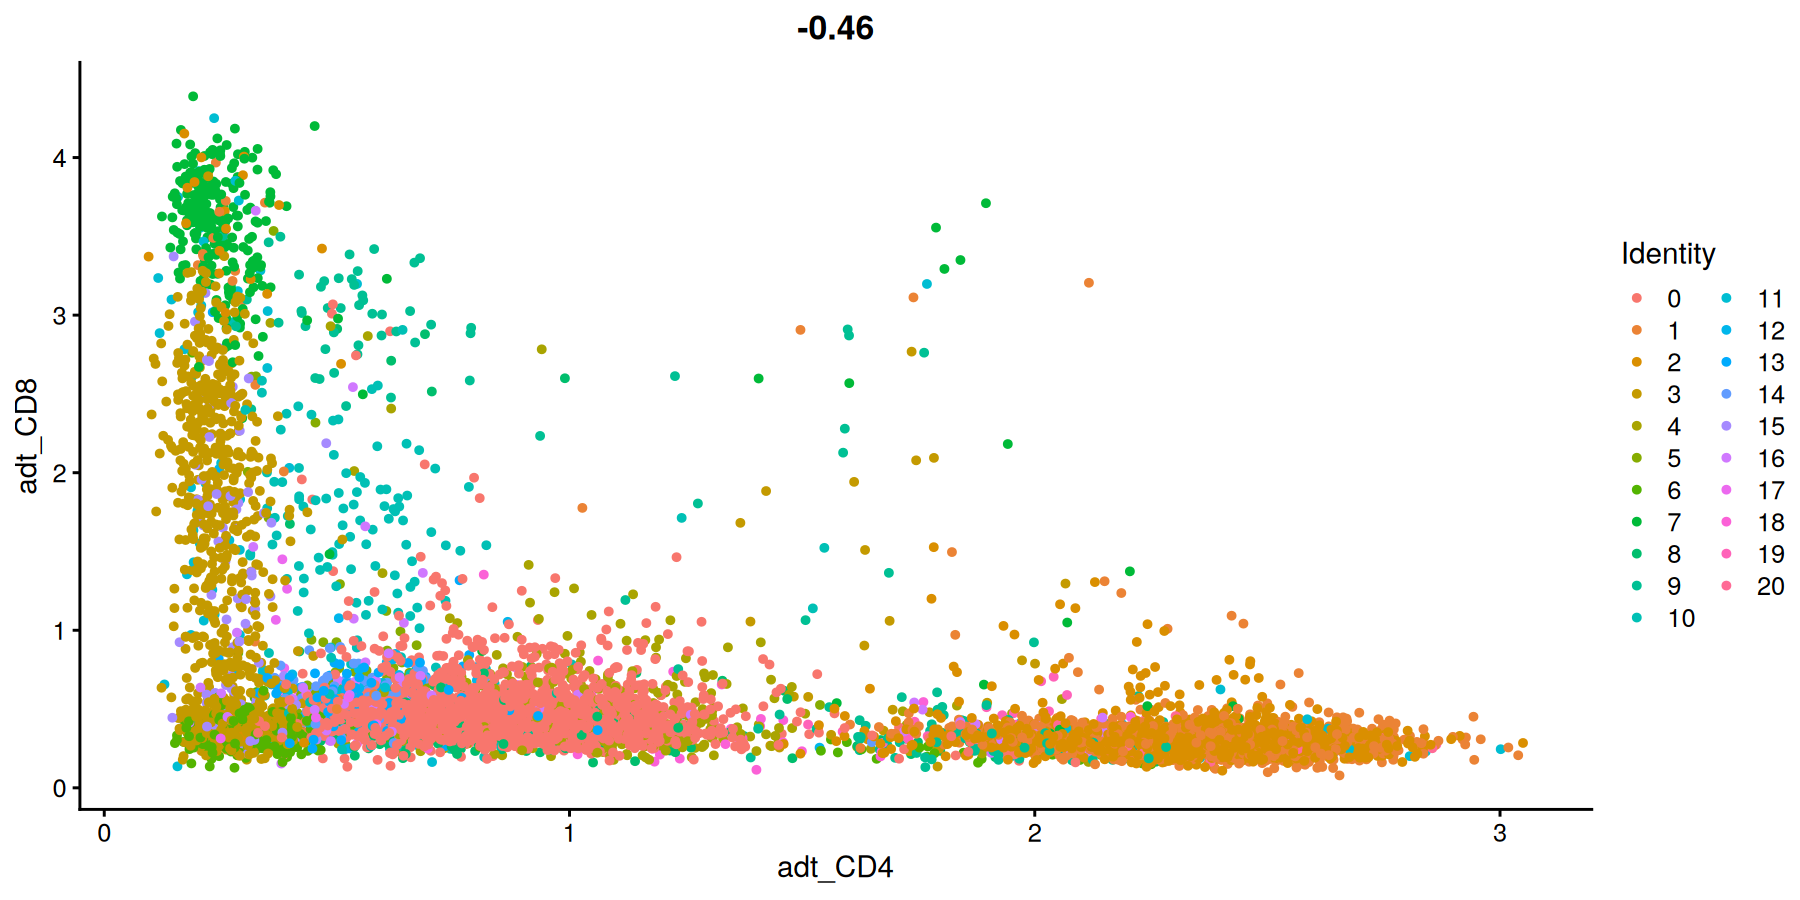

In [34]:
FeatureScatter(cbmc, feature1 = "adt_CD4", feature2 = "adt_CD8")

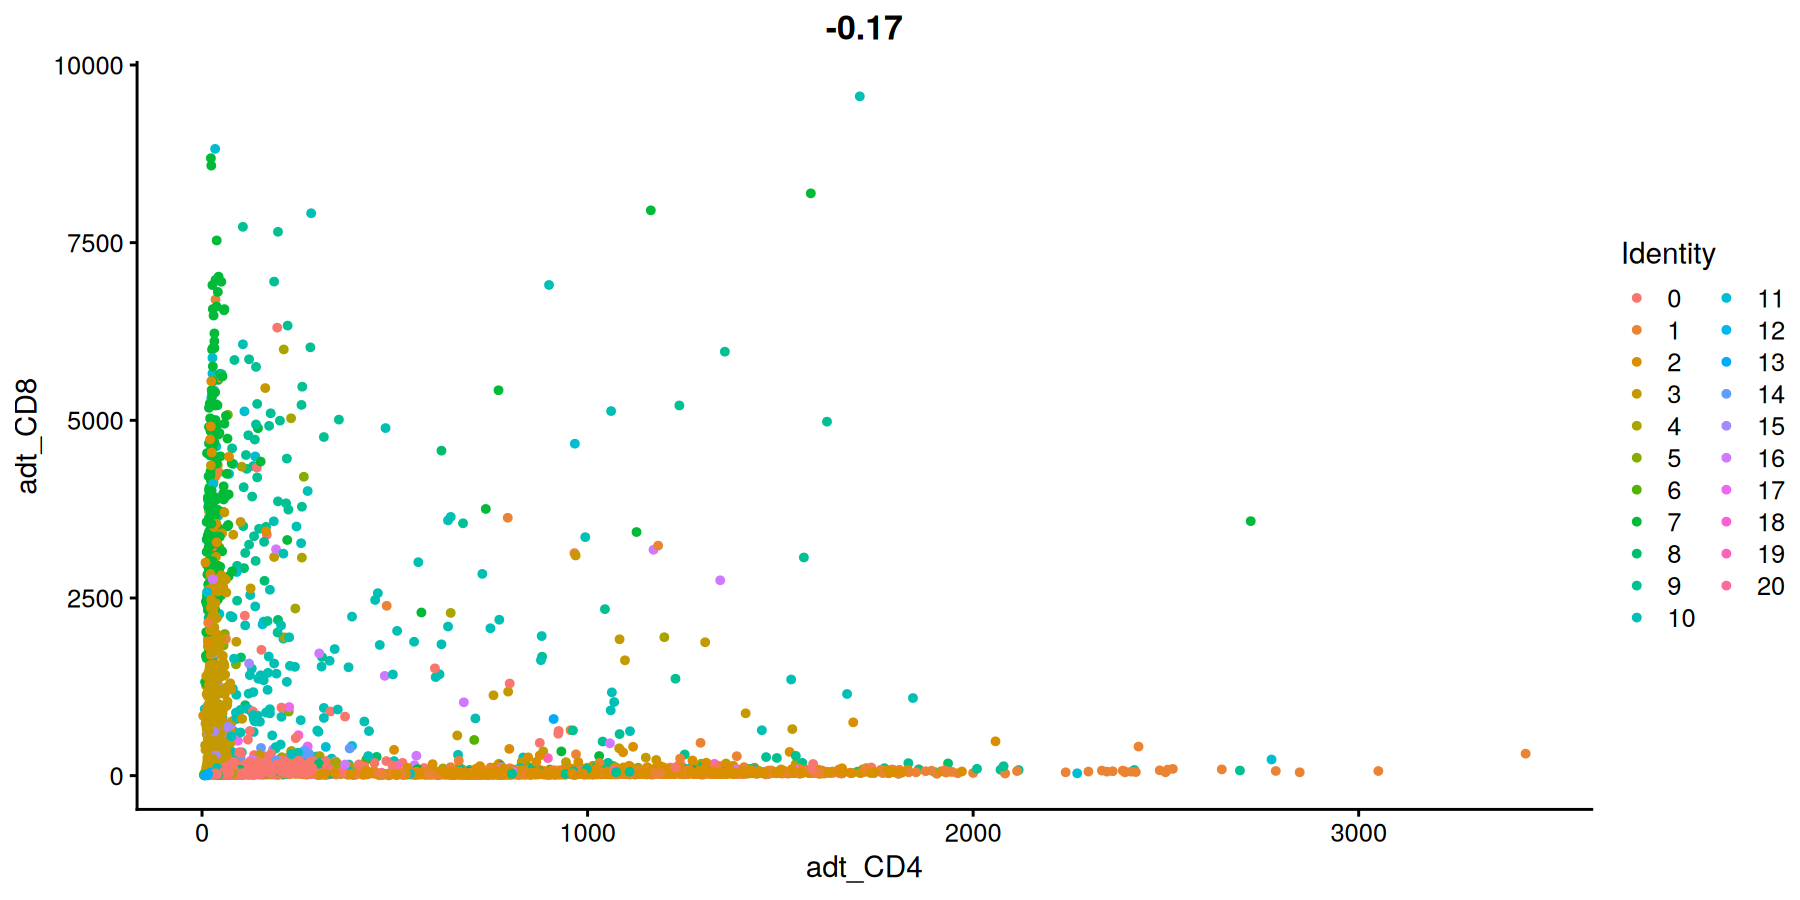

In [35]:
# Let's look at the raw (non-normalized) ADT counts. You can see the values are quite high,
# particularly in comparison to RNA values This is due to the significantly higher protein
# copy number in cells, which significantly reduces 'drop-out' in ADT data
FeatureScatter(cbmc, feature1 = "adt_CD4", feature2 = "adt_CD8", slot = "counts")

In [36]:
cat("Identify differentially expressed proteins between clusters")

Identify differentially expressed proteins between clusters

In [38]:
# https://broadinstitute.github.io/2020_scWorkshop/cite-seq.html

In [37]:
# Downsample the clusters to a maximum of 300 cells each (makes the heatmap easier to see for
# small clusters)
cbmc.small <- subset(cbmc, downsample = 300)

# Find protein markers for all clusters, and draw a heatmap
adt.markers <- FindAllMarkers(cbmc.small, assay = "ADT", only.pos = TRUE)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18

Calculating cluster 19

Calculating cluster 20



Centering and scaling data matrix



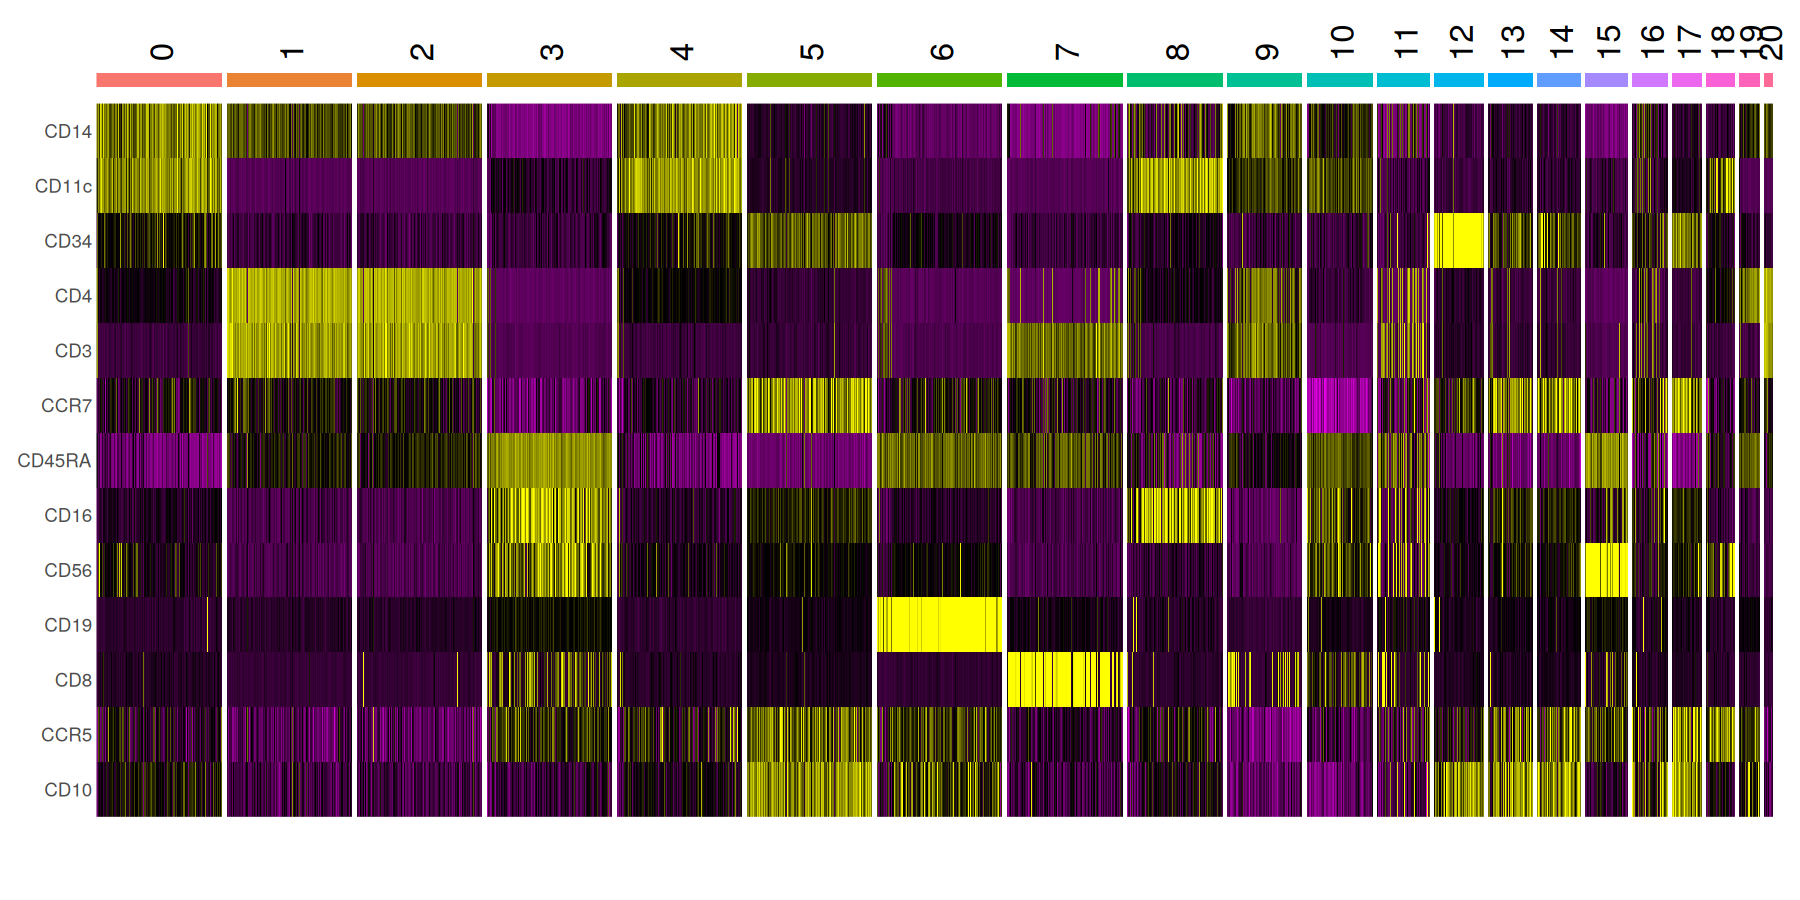

In [40]:
# Step 1: Set ADT as default assay
DefaultAssay(cbmc.small) <- "ADT"

# Step 2: Scale the ADT data first
cbmc.small <- ScaleData(cbmc.small, assay = "ADT")

# Step 3: Now run DoHeatmap
DoHeatmap(cbmc.small, 
          features = unique(adt.markers$gene), 
          assay = "ADT", 
          angle = 90) + NoLegend()